In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

pd.set_option('display.max_columns', None)
print("Libraries loaded ✅")

Libraries loaded ✅


In [4]:
# Load data
ads = pd.read_csv('../data/raw/global_ads_performance_dataset.csv')
cats = pd.read_csv('../data/raw/cookie_cats.csv')

print("=== ADS DATASET ===")
print(f"Shape: {ads.shape}")
print(ads.head(3))

print("\n=== COOKIE CATS DATASET ===")
print(f"Shape: {cats.shape}")
print(cats.head(3))

=== ADS DATASET ===
Shape: (1800, 14)
         date    platform campaign_type    industry country  impressions  \
0  2024-01-21  Google Ads        Search     Fintech     UAE        59886   
1  2024-01-22  TikTok Ads        Search      EdTech      UK       135608   
2  2024-06-15  TikTok Ads         Video  Healthcare     USA        92313   

   clicks     CTR   CPC  ad_spend  conversions    CPA   revenue   ROAS  
0    2113  0.0353  1.26   2662.38          159  16.74   4803.43   1.80  
1    5220  0.0385  1.18   6159.60          411  14.99  64126.68  10.41  
2    5991  0.0649  0.85   5092.35          267  19.07  10489.07   2.06  

=== COOKIE CATS DATASET ===
Shape: (90189, 5)
   userid  version  sum_gamerounds  retention_1  retention_7
0     116  gate_30               3        False        False
1     337  gate_30              38         True        False
2     377  gate_40             165         True        False


In [5]:
print("=== ADS INFO ===")
print(ads.info())
print("\nMissing values:\n", ads.isnull().sum())

print("\n=== COOKIE CATS INFO ===")
print(cats.info())
print("\nMissing values:\n", cats.isnull().sum())

=== ADS INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1800 non-null   str    
 1   platform       1800 non-null   str    
 2   campaign_type  1800 non-null   str    
 3   industry       1800 non-null   str    
 4   country        1800 non-null   str    
 5   impressions    1800 non-null   int64  
 6   clicks         1800 non-null   int64  
 7   CTR            1800 non-null   float64
 8   CPC            1800 non-null   float64
 9   ad_spend       1800 non-null   float64
 10  conversions    1800 non-null   int64  
 11  CPA            1800 non-null   float64
 12  revenue        1800 non-null   float64
 13  ROAS           1800 non-null   float64
dtypes: float64(6), int64(3), str(5)
memory usage: 197.0 KB
None

Missing values:
 date             0
platform         0
campaign_type    0
industry         0
country          0
impre

In [6]:
# === ADS DATASET ===
print("=== PLATFORMS ===")
print(ads['platform'].value_counts())

print("\n=== CAMPAIGN TYPES ===")
print(ads['campaign_type'].value_counts())

print("\n=== DATE RANGE ===")
print("From:", ads['date'].min())
print("To:", ads['date'].max())

print("\n=== KEY METRICS SUMMARY ===")
print(ads[['spend', 'impressions', 'clicks', 'installs', 'revenue']].describe())

=== PLATFORMS ===
platform
Google Ads    720
Meta Ads      630
TikTok Ads    450
Name: count, dtype: int64

=== CAMPAIGN TYPES ===
campaign_type
Search      477
Video       456
Shopping    447
Display     420
Name: count, dtype: int64

=== DATE RANGE ===
From: 2024-01-01
To: 2024-12-30

=== KEY METRICS SUMMARY ===


KeyError: "['spend', 'installs'] not in index"

In [7]:
print("ADS COLUMNS:", ads.columns.tolist())

ADS COLUMNS: ['date', 'platform', 'campaign_type', 'industry', 'country', 'impressions', 'clicks', 'CTR', 'CPC', 'ad_spend', 'conversions', 'CPA', 'revenue', 'ROAS']


In [8]:
print("=== PLATFORMS ===")
print(ads['platform'].value_counts())

print("\n=== CAMPAIGN TYPES ===")
print(ads['campaign_type'].value_counts())

print("\n=== DATE RANGE ===")
print("From:", ads['date'].min())
print("To:", ads['date'].max())

print("\n=== KEY METRICS SUMMARY ===")
print(ads[['ad_spend', 'impressions', 'clicks', 'conversions', 'revenue', 'ROAS', 'CPC', 'CTR']].describe())


=== PLATFORMS ===
platform
Google Ads    720
Meta Ads      630
TikTok Ads    450
Name: count, dtype: int64

=== CAMPAIGN TYPES ===
campaign_type
Search      477
Video       456
Shopping    447
Display     420
Name: count, dtype: int64

=== DATE RANGE ===
From: 2024-01-01
To: 2024-12-30

=== KEY METRICS SUMMARY ===
           ad_spend    impressions        clicks  conversions        revenue  \
count   1800.000000    1800.000000   1800.000000  1800.000000    1800.000000   
mean    6171.527272  102919.018889   3962.675556   181.562222   30101.850450   
std     5776.996958   55740.900690   2941.858037   171.424239   34560.032941   
min       58.000000    5059.000000     91.000000     2.000000     142.690000   
25%     1966.587500   54948.000000   1678.000000    59.000000    7275.757500   
50%     4393.860000  103653.000000   3318.000000   130.000000   18362.965000   
75%     8455.830000  150470.250000   5628.000000   252.250000   38963.385000   
max    38453.320000  199650.000000  16660.00

In [9]:
print("=== VERSION DISTRIBUTION ===")
print(cats['version'].value_counts())

print("\n=== RETENTION RATES ===")
print("D1 Retention:", round(cats['retention_1'].mean() * 100, 2), "%")
print("D7 Retention:", round(cats['retention_7'].mean() * 100, 2), "%")

print("\n=== RETENTION BY VERSION ===")
print(cats.groupby('version')[['retention_1', 'retention_7']].mean().round(4) * 100)

print("\n=== GAME ROUNDS SUMMARY ===")
print(cats['sum_gamerounds'].describe())

=== VERSION DISTRIBUTION ===
version
gate_40    45489
gate_30    44700
Name: count, dtype: int64

=== RETENTION RATES ===
D1 Retention: 44.52 %
D7 Retention: 18.61 %

=== RETENTION BY VERSION ===
         retention_1  retention_7
version                          
gate_30        44.82        19.02
gate_40        44.23        18.20

=== GAME ROUNDS SUMMARY ===
count    90189.000000
mean        51.872457
std        195.050858
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max      49854.000000
Name: sum_gamerounds, dtype: float64


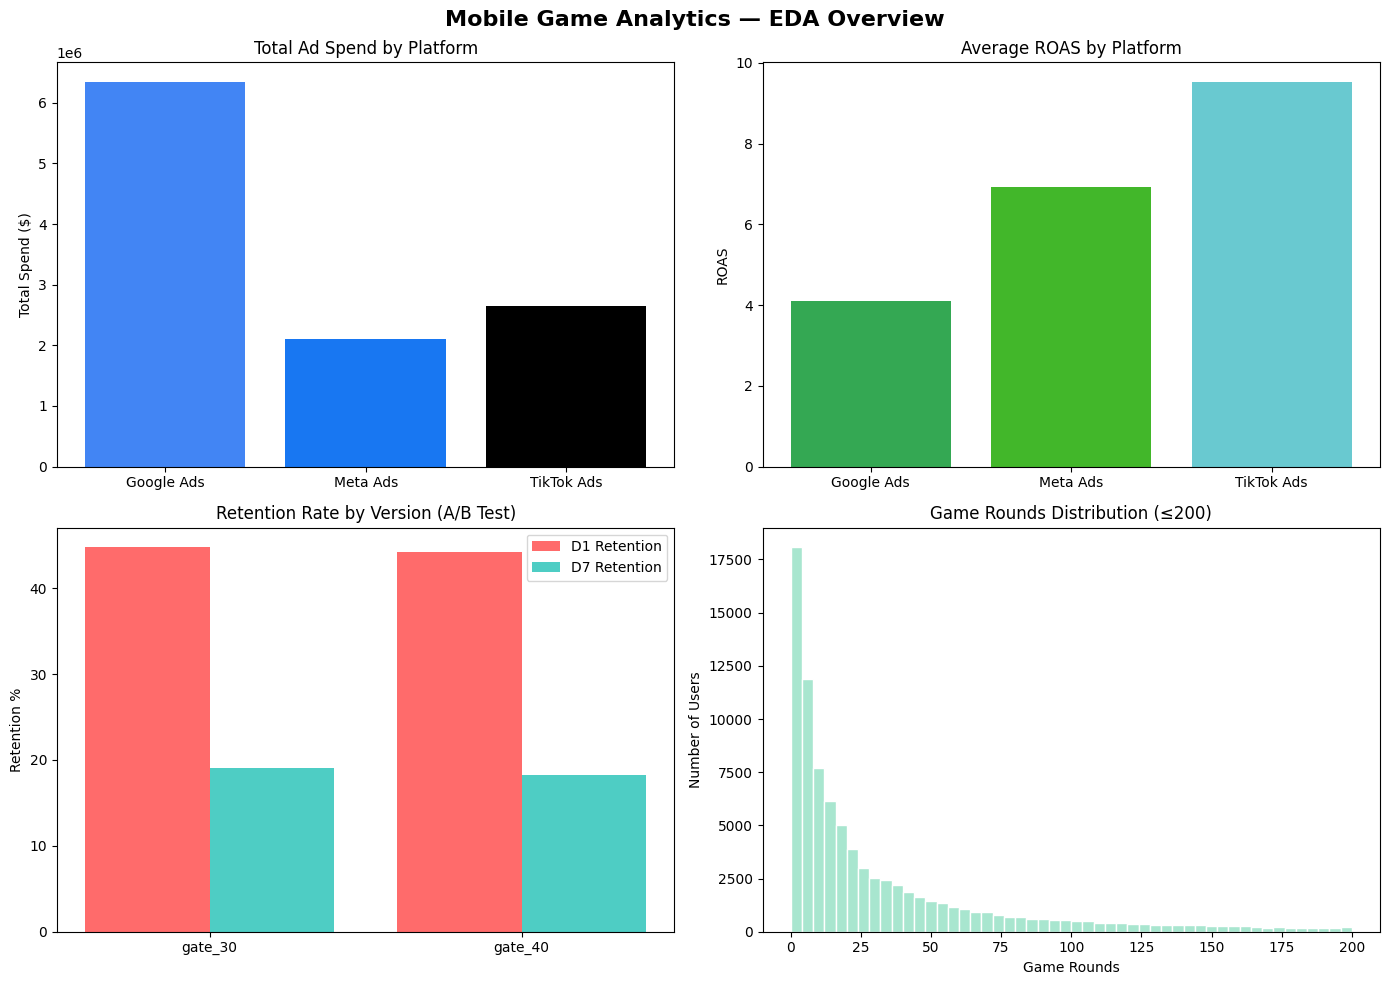

Chart saved to images/ ✅


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Mobile Game Analytics — EDA Overview', fontsize=16, fontweight='bold')

# 1. Ads spend by platform
platform_spend = ads.groupby('platform')['ad_spend'].sum()
axes[0,0].bar(platform_spend.index, platform_spend.values, color=['#4285F4','#1877F2','#000000'])
axes[0,0].set_title('Total Ad Spend by Platform')
axes[0,0].set_ylabel('Total Spend ($)')

# 2. ROAS by platform
platform_roas = ads.groupby('platform')['ROAS'].mean()
axes[0,1].bar(platform_roas.index, platform_roas.values, color=['#34A853','#42B72A','#69C9D0'])
axes[0,1].set_title('Average ROAS by Platform')
axes[0,1].set_ylabel('ROAS')

# 3. D1 vs D7 Retention by version
versions = ['gate_30', 'gate_40']
d1 = [44.82, 44.23]
d7 = [19.02, 18.20]
x = range(len(versions))
axes[1,0].bar([i-0.2 for i in x], d1, width=0.4, label='D1 Retention', color='#FF6B6B')
axes[1,0].bar([i+0.2 for i in x], d7, width=0.4, label='D7 Retention', color='#4ECDC4')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(versions)
axes[1,0].set_title('Retention Rate by Version (A/B Test)')
axes[1,0].set_ylabel('Retention %')
axes[1,0].legend()

# 4. Game rounds distribution (capped at 200)
cats_filtered = cats[cats['sum_gamerounds'] <= 200]
axes[1,1].hist(cats_filtered['sum_gamerounds'], bins=50, color='#A8E6CF', edgecolor='white')
axes[1,1].set_title('Game Rounds Distribution (≤200)')
axes[1,1].set_xlabel('Game Rounds')
axes[1,1].set_ylabel('Number of Users')

plt.tight_layout()
plt.savefig('../images/01_eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to images/ ✅")